# K-Means Customer Segmentation: Automated Clustering and Evaluation
### This notebook:
* preprocesses customer demographic data, 
* determines the optimal number of groups using Elbow method and Silhouette analysis,
* implements a manual K-Means algorithm to segment customers by age and income.
* provides insights, vizualizations and interpretation of the results.

### Description:

A company has a large database of customer information, including the customer's age and annual income. 

The goal is to use the K-Means algorithmto segment the customers into different groups based on their age and
income. 

You will be provided with a script to create a fitting dataset, and are supposed to implement K-Means in order to find clusters in the data.

### Tasks:
If presented with a task such as these, the steps to follow are:
1. Load the customer data into a pandas DataFrame.

2. Preprocess the data, if necessary (e.g., normalize the variables, handle
missing values, etc.).

3. Visualize the data using a scatter plot to get an idea of the distribution
and potential clusters.

4. Choose the number of clusters (K) to use in the algorithm.

5. Initialize the centroids randomly.

6. Implement the two main steps of the K-Means algorithm (assigning each data point to its closest centroid and recalculating the centroids) in a loop until convergence.

7. Visualize the final clusters using a scatter plot, with different colors for each cluster.

8. Interpret the results, and draw insights about the customer segments.

9. This task should give you a hands-on experience with the K-Means algorithm, and help you understand how to apply it to real-world data.

Owner: Evgeniya Englert

Last update: 2026-02-23

In [24]:
# Packages needed for this lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Script to create Dataset

Here is the script to create a synthetic dataset with multiple distinct clusters
and the two features being the age of customers and the annual income:

In [25]:
# Set the number of data points
N = 1000
# Generate the age of customers and annual income data for three distinct clusters
np.random.seed(0)
cluster_1 = np.column_stack((np.random.normal(35, 10, N//3), np.random.normal(50_000, 10_000, N//3)))
cluster_2 = np.column_stack((np.random.normal(50, 10, N//3), np.random.normal(80_000, 10_000, N//3)))
cluster_3 = np.column_stack((np.random.normal(65, 10, N//3), np.random.normal(40_000, 10_000, N//3)))

# Combine the data into a single array
X = np.concatenate((cluster_1, cluster_2, cluster_3), axis=0)


### 1. Load the customer data into a pandas DataFrame.

In [26]:
# 1. Load the customer data into a pandas DataFrame.
# Convert the array to a pandas DataFrame
df = pd.DataFrame(X, columns=['Age', 'Annual Income'])
# Print the first 5 rows of the data
print(df.head())

         Age  Annual Income
0  52.640523   38161.193598
1  39.001572   23408.277620
2  44.787380   56063.195244
3  57.408932   32441.094166
4  53.675580   54509.344618


### 2. Preprocess the data, if necessary (e.g., normalize the variables, handle missing values, etc.).
#### Summary of Steps:
* **Handle Missing Values:** Even though the simulated data is clean, df.dropna() or df.fillna() are standard for real-world sets.
* **Standardization:** Using z = (x - mu)/sigma ensures that a $10,000 difference in income isn't "weighted" more heavily than a 10-year difference in age.
* **Outlier Detection:** If we have extreme outliers, we might consider RobustScaler, which uses the interquartile range (IQR) instead of the mean and standard deviation.

In [27]:
# 2. Preprocess the data, if necessary (e.g., normalize the variables, handle missing values, etc.).
# Preprocessing for KMeans:
# Because K-Means relies on the Euclidean distance between points, variables with larger magnitudes (like Annual Income) will dominate the clusters if they aren't normalized.

# 1. Data Integrity & Exploratory Checks
# Before transforming the data, we need to ensure there are no "surprises" like null values or extreme outliers that could pull the centroids of your clusters away from the actual groups.

# Check for missing values: No missing values in the data
print("Missing values per column:")
print(df.isnull().sum())

# Basic descriptive statistics
print("\nData Summary:")
print(df.describe())

Missing values per column:
Age              0
Annual Income    0
dtype: int64

Data Summary:
              Age  Annual Income
count  999.000000     999.000000
mean    50.085499   56289.006060
std     15.765813   19876.245539
min      7.274072   15624.356408
25%     38.580850   40497.750302
50%     50.114989   52098.501264
75%     61.743544   74057.863913
max     91.805708  111709.747733


In [28]:
# 2. Preprocessing for K-Means
# Since our data is simulated and clean of nulls, the most critical step is Feature Scaling. 
# We typically use StandardScaler to give both features a mean of 0 and a variance of 1.

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
# We create a new array 'X_scaled' to keep the original df intact for later analysis
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for easier inspection
df_scaled = pd.DataFrame(X_scaled, columns=['Age', 'Annual Income'])

print("\nScaled Data (First 5 rows):")
print(df_scaled.head())


Scaled Data (First 5 rows):
        Age  Annual Income
0  0.162142      -0.912491
1 -0.703388      -1.655101
2 -0.336219      -0.011367
3  0.464746      -1.200421
4  0.227827      -0.089582


### 3. Visualize the data using a scatter plot to get an idea of the distribution and potential clusters.

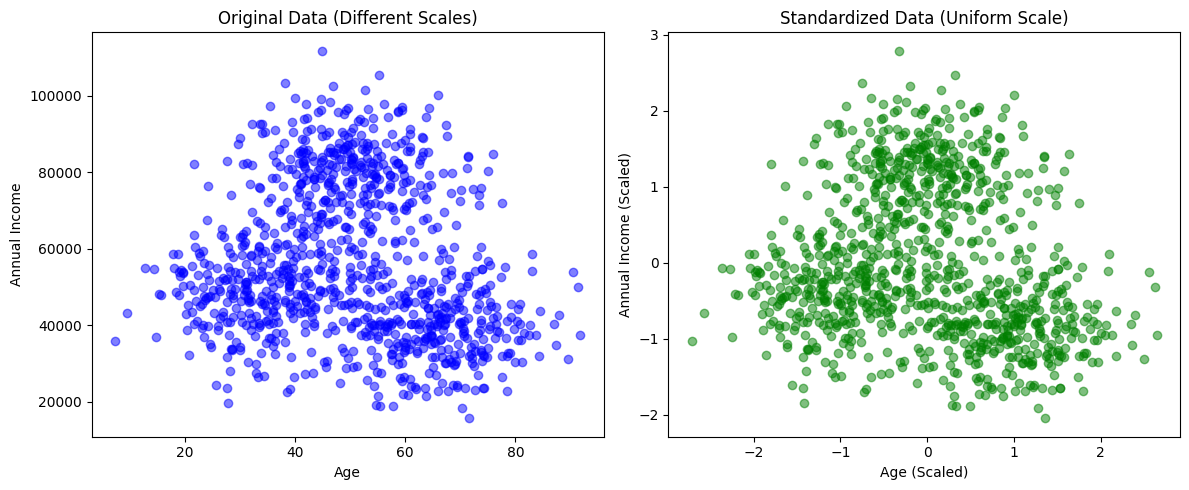

In [29]:
# 3. Visualize the data using a scatter plot to get an idea of the distribution and potential clusters.
# Visualizing the "Before" and "After"
# It’s always a good idea to visualize the distribution. Notice how the shape of the data stays the same, but the axes change to a similar scale.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original Data
ax1.scatter(df['Age'], df['Annual Income'], alpha=0.5, c='blue')
ax1.set_title('Original Data (Different Scales)')
ax1.set_xlabel('Age')
ax1.set_ylabel('Annual Income')

# Scaled Data
ax2.scatter(df_scaled['Age'], df_scaled['Annual Income'], alpha=0.5, c='green')
ax2.set_title('Standardized Data (Uniform Scale)')
ax2.set_xlabel('Age (Scaled)')
ax2.set_ylabel('Annual Income (Scaled)')

plt.tight_layout()
plt.show()

### 4. Choose the number of clusters (K) to use in the algorithm.
To find the optimal number of clusters for the data, the **Elbow Method** is the standard approach. 

It calculates the Within-Cluster Sum of Squares (WCSS)—also known as inertia—for various values of **K**.

As **K** increases, the distance between points and their centroids decreases. 

We are looking for the "elbow" point where the rate of decrease shifts from sharp to shallow, indicating diminishing returns for adding more clusters.

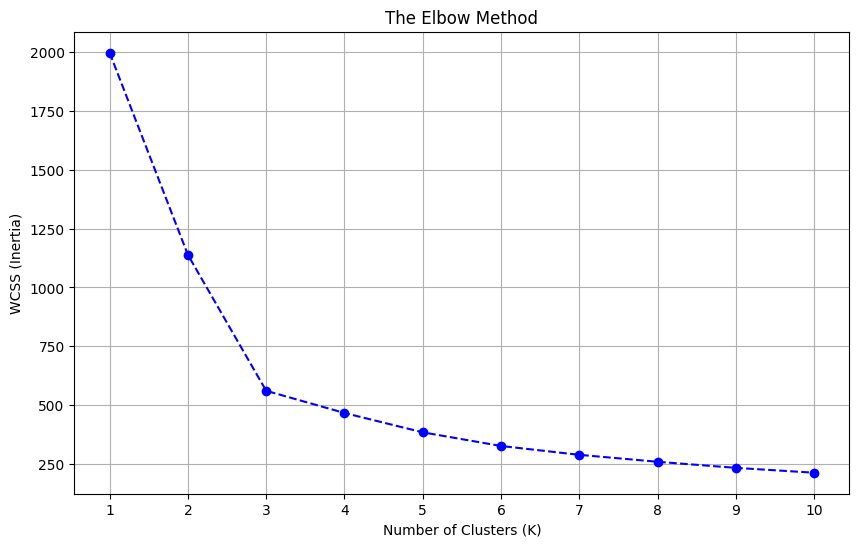

In [30]:
# 4. Choose the number of clusters (K) to use in the algorithm: The Elbow Method

# Calculate WCSS for different values of K
wcss = []
k_range = range(1, 11)

for k in k_range:
    # Use 'k-means++' to avoid the random initialization trap
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


### Interpretation:

After running this code, we noticed a steep drop-off at first.

At **K=1** and **K=2**: The error (WCSS) is very high because the groups are too broad.

At **K=3**: We see a distinct "bend" or elbow. Since our simulated data was built using 3 distinct clusters, the math should reflect that perfectly.

After **K=3**: The line flattens out. Adding a fourth or fifth cluster doesn't significantly improve the "tightness" of the groups; it just over-segments the data.

**Recommendation: To use K=3.**

### Alternative method to define the number of clusters: **The Silhouette Score**

If the "elbow" is hard to see (which happens often with real-world, messy data), we can use the Silhouette Score. 

It measures how similar an object is to its own cluster compared to other clusters. 

A score closer to 1 is better.


Silhouette Scores: {2: 0.41034619776650283, 3: 0.4978574550683554, 4: 0.4109478696008225, 5: 0.3682994620251802, 6: 0.3420747542647807, 7: 0.3351932101061556, 8: 0.33542773063384723, 9: 0.3230755489408999, 10: 0.32536807177152366, 11: 0.32765958028775954}
Optimal number of clusters based on Silhouette Score: 3 (Score: 0.4979)


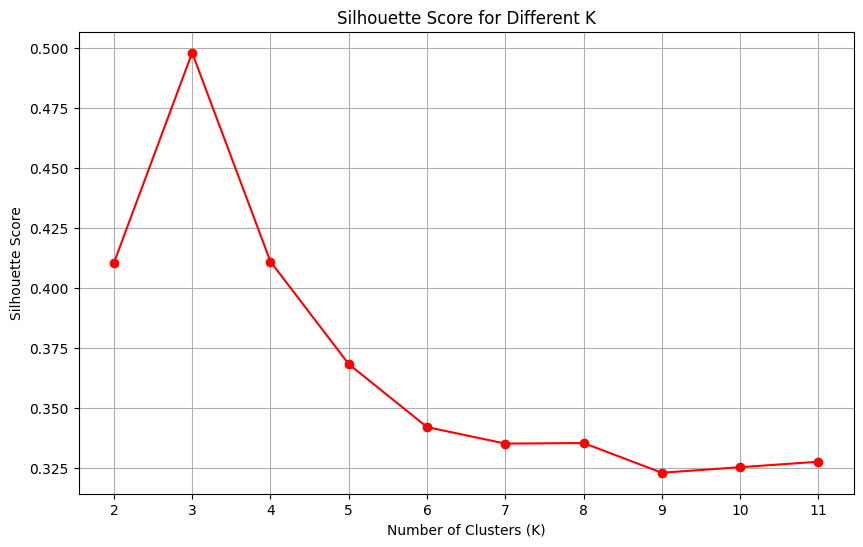

In [31]:
# The Silhouette Score is a measure of how similar an object is to its own cluster compared to other clusters. 
# It ranges from -1 to 1, where a higher score indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. 
# A score close to 0 indicates that the object is on or very close to the decision boundary between two neighboring clusters, while a negative score indicates that those samples might have been assigned to the wrong cluster.

# Calculate Silhouette Scores (k=2 to 11)
sil_scores = []
k_range = range(2, 12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_range, sil_scores, marker='o', linestyle='-', color='r')
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('silhouette_score_plot.png')

# Determine the best K
best_k = k_range[np.argmax(sil_scores)]
best_score = max(sil_scores)

print(f"Silhouette Scores: {dict(zip(k_range, sil_scores))}")
print(f"Optimal number of clusters based on Silhouette Score: {best_k} (Score: {best_score:.4f})")

**Recommendation: To use K=3.**

### 5. Initialize the centroids randomly.

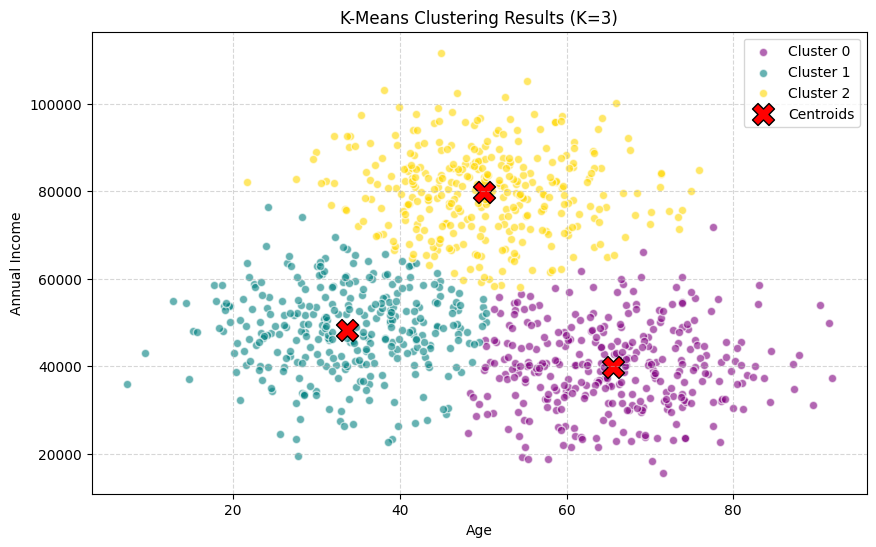

Cluster Centers (Original Scale):
         Age  Annual Income
0  65.595257   39888.943601
1  33.688539   48322.649528
2  50.144678   79903.202372


In [32]:
# K-Means (K=3 as best_k, Random Initialization)
kmeans = KMeans(n_clusters=best_k, init='random', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the results back to the original DataFrame
df['Cluster'] = cluster_labels

# Visualize the Final Clusters
plt.figure(figsize=(10, 6))

# Scatter plot for each cluster
colors = ['purple', 'teal', 'gold']
for i in range(3):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Age'], cluster_data['Annual Income'], 
                c=colors[i], label=f'Cluster {i}', alpha=0.6, edgecolors='w')

# Plotting the Centroids
# Note: Centroids are in scaled coordinates, so we inverse transform them back to original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centroids[:, 0], centroids[:, 1], 
            s=250, marker='X', c='red', label='Centroids', edgecolors='black')

plt.title('K-Means Clustering Results (K=3)')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# View Cluster Centers (Means)
print("Cluster Centers (Original Scale):")
centroids_df = pd.DataFrame(centroids, columns=['Age', 'Annual Income'])
print(centroids_df)

### Key Details in this KMeans Implementation:
* **init='random':** This fulfills your requirement to pick starting centroids randomly from the data points.

* **n_init=10:** Random initialization can sometimes lead to "local optima" (poor clustering) if the first random pick is bad. Setting n_init ensures the algorithm runs multiple times to find the most stable result.

* **Centroid Mapping:** Because we performed the clustering on scaled data, the kmeans.cluster_centers_ are also scaled. We use scaler.inverse_transform() to bring those coordinates back into "Years" and "Dollars" so they make sense on your final graph.

### 6. Implement the two main steps of the K-Means algorithm (assigning each data point to its closest centroid and recalculating the centroids) in a loop until convergence.

In [33]:
# Implement the two main steps of the K-Means algorithm (assigning each data point to its closest centroid and recalculating the centroids) in a loop until convergence.

# Initialize Centroids Randomly
k = best_k
np.random.seed(42)
# Select k random indices from the scaled data
random_indices = np.random.choice(len(X_scaled), k, replace=False)
centroids = X_scaled[random_indices]

# Convergence parameters
max_iterations = 100
tolerance = 1e-4

for i in range(max_iterations):
    # --- STEP 1: ASSIGNMENT ---
    # Calculate Euclidean distance from each point to each centroid
    # Using broadcasting for efficiency: (1000, 1, 2) - (1, 3, 2)
    distances = np.linalg.norm(X_scaled[:, np.newaxis] - centroids, axis=2)
    
    # Assign each point to the closest centroid (index 0, 1, or 2)
    labels = np.argmin(distances, axis=1)
    
    # --- STEP 2: UPDATE ---
    # Store old centroids to check for convergence
    old_centroids = centroids.copy()
    
    # Recalculate centroids as the mean of assigned points
    for j in range(k):
        points_in_cluster = X_scaled[labels == j]
        if len(points_in_cluster) > 0:
            centroids[j] = points_in_cluster.mean(axis=0)
    
    # --- CHECK CONVERGENCE ---
    # If centroids shift by less than our tolerance, we stop early
    shift = np.linalg.norm(centroids - old_centroids)
    if shift < tolerance:
        print(f"Converged at iteration {i}")
        break

Converged at iteration 6


### 7. Visualize the final clusters using a scatter plot, with different colors for each cluster.

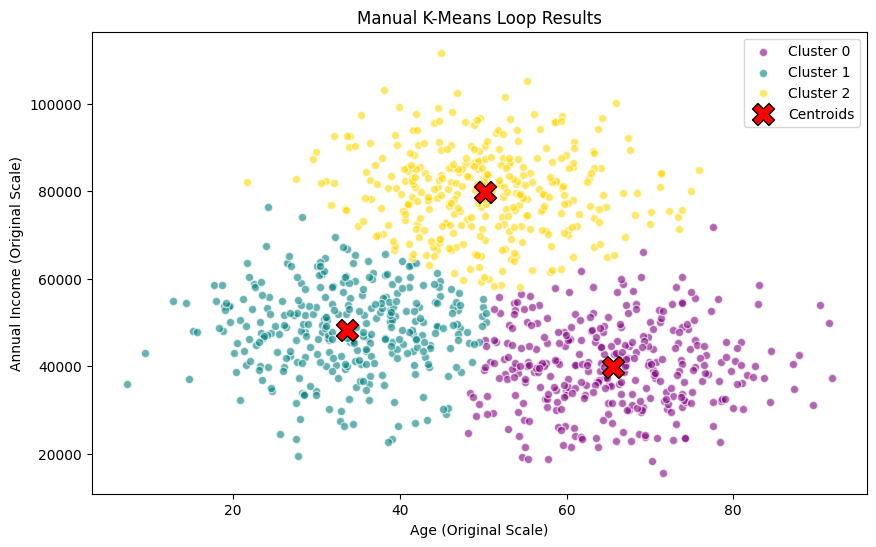

Cluster Centers (Original Scale):
         Age  Annual Income
0  50.224704   79879.758794
1  65.559548   39793.785531
2  33.688539   48322.649528


In [34]:
# Visualize the Final Clusters
plt.figure(figsize=(10, 6))

# Scatter plot for each cluster
colors = ['purple', 'teal', 'gold']
for i in range(3):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Age'], cluster_data['Annual Income'], 
                c=colors[i], label=f'Cluster {i}', alpha=0.6, edgecolors='w')    

# Plotting the Centroids
# Note: Centroids are in scaled coordinates, so we inverse transform them back to original scale
centroids_original_scale = scaler.inverse_transform(centroids)

plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1], 
            s=250, marker='X', c='red', label='Centroids', edgecolors='black')

plt.title('Manual K-Means Loop Results')
plt.xlabel('Age (Original Scale)')
plt.ylabel('Annual Income (Original Scale)')
plt.legend()
plt.show()

# View Cluster Centers (Means)
print("Cluster Centers (Original Scale):")
centroids_df = pd.DataFrame(centroids_original_scale, columns=['Age', 'Annual Income'])
print(centroids_df)

### 8. Interpret the results, and draw insights about the customer segments.
### Understanding 3 Clusters
We see three distinct clusters:
* **Younger/Middle Income:** Around age 34, earning ~$48k.
* **Middle-Aged/High Income:** Around age 50, earning ~$80k.
* **Older/Lower Income:** Around age 66, earning ~$40k.

### 9. This task should give you a hands-on experience with the K-Means algorithm, and help you understand how to apply it to real-world data.
Done.